# Full CIFAR-10 layer sensitivity: custom INT8 PTQ vs custom codebook W8

This notebook performs the complete one-layer-at-a-time weight-quantization experiment on the trained ResNet-18 using **all 10,000 official CIFAR-10 test images**. It compares two mathematical, weight-only methods under identical tensor coverage:

1. **Custom PTQ W8:** symmetric, per-output-channel signed INT8 weights.
2. **Custom codebook W8:** scalar codebook quantization with `K=256` and `vector_dim=1`, so every weight receives one 8-bit assignment.

Each layer experiment starts from the same FP32 checkpoint, quantizes exactly one kernel, leaves all remaining weights FP32, and evaluates all 10,000 images. Activations and Keras arithmetic remain FP32; no fake-quantization nodes or retraining are used. Reconstructed weights measure numerical and task-level effects, not integer-runtime latency.

In [1]:
from pathlib import Path
import gc
import json
import platform
import sys
import time

import keras
import keras_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.stats import binomtest, pearsonr, spearmanr
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("Run this notebook from the project root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models import CIFAR10_CLASS_NAMES
from src.quantization.custom_quantization import (
    codebook_vectorize_model,
    custom_ptq,
    dequantize_tensor,
    reconstruct_codebook_tensor,
)

print(f"Python: {sys.version.split()[0]} ({sys.executable})")
print(f"TensorFlow: {tf.__version__}; Keras: {keras.__version__}")
print(f"SciPy: {scipy.__version__}; hardware: {platform.platform()}")

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.13.7 (/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/bin/python)
TensorFlow: 2.20.0; Keras: 3.14.1
SciPy: 1.18.0; hardware: macOS-26.5.2-arm64-arm-64bit-Mach-O


## 1. Fixed experimental configuration

Prediction and reconstructed-weight caches make the multi-hour experiment resumable. Change `CACHE_VERSION` whenever the checkpoint or quantization mathematics changes. `FORCE_RECOMPUTE=True` ignores existing prediction and reconstruction caches.

In [2]:
MODEL_PATH = (
    PROJECT_ROOT / "artifacts" / "resnet18_cifar10_training"
    / "resnet18_cifar10_fp32.keras"
)
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "resnet18_full_layer_sensitivity"
CACHE_VERSION = "v1_w8_per_channel_vs_k256_scalar_full_test"
CACHE_DIR = OUTPUT_DIR / "cache" / CACHE_VERSION
PREDICTION_CACHE_DIR = CACHE_DIR / "predictions"
RECONSTRUCTION_CACHE_DIR = CACHE_DIR / "reconstructed_weights"

NUM_TEST_IMAGES = 10_000
BATCH_SIZE = 32
QUANTIZE_MIN_RANK = 2
PTQ_PER_CHANNEL = True
CODEBOOK_SIZE = 256
CODEBOOK_VECTOR_DIM = 1
CODEBOOK_DTYPE = np.float32
CODEBOOK_ITERATIONS = 30
CODEBOOK_MAX_SAMPLES = 100_000
RANDOM_SEED = 42
BOOTSTRAP_REPETITIONS = 2_000
TOP_K_VALUES = (1, 3, 5)
RANDOM_CONTROL_REPETITIONS = 10
FORCE_RECOMPUTE = False

METHODS = {
    "ptq_w8": "Custom per-channel INT8 PTQ",
    "codebook_w8": "Custom scalar codebook W8 (K=256)",
}

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing trained model: {MODEL_PATH}. Run notebook 06 first.")
for directory in (OUTPUT_DIR, PREDICTION_CACHE_DIR, RECONSTRUCTION_CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f"Checkpoint: {MODEL_PATH}")
print(f"Required test images: {NUM_TEST_IMAGES:,}")
print(f"Cache: {CACHE_DIR}")

Checkpoint: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_cifar10_training/resnet18_cifar10_fp32.keras
Required test images: 10,000
Cache: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_full_layer_sensitivity/cache/v1_w8_per_channel_vs_k256_scalar_full_test


## 2. Load the immutable FP32 checkpoint and complete test set

In [3]:
model = keras.models.load_model(MODEL_PATH, compile=False)
(_, _), (test_images, test_labels) = keras.datasets.cifar10.load_data()
test_labels = test_labels.reshape(-1).astype(np.int32)
assert len(test_images) == len(test_labels) == NUM_TEST_IMAGES, (
    f"Expected the full {NUM_TEST_IMAGES:,}-image CIFAR-10 test set; "
    f"received {len(test_images):,}."
)

image_converter = keras_hub.layers.ResNetImageConverter(
    image_size=(224, 224),
    scale=[0.017124753831663668, 0.01750700280112045, 0.017429193899782133],
    offset=[-2.1179039301310043, -2.0357142857142856, -1.8044444444444445],
    interpolation="bicubic",
    crop_to_aspect_ratio=True,
)

def preprocess_images(images):
    return image_converter(images)

baseline_weights = [weight.numpy() for weight in model.weights]
fp32_parameter_bytes = int(sum(values.nbytes for values in baseline_weights))
print(f"Loaded all {len(test_images):,} CIFAR-10 test images.")
print(f"FP32 parameter storage: {fp32_parameter_bytes / 1024**2:.2f} MiB")
model.summary(expand_nested=True)

Loaded all 10,000 CIFAR-10 test images.
FP32 parameter storage: 42.69 MiB


Model: "resnet18_cifar10_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ images (InputLayer)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_net_backbone                │ (None, 7, 7, 512)      │    11,186,112 │
│ (ResNetBackbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer (InputLayer)   │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_pad (ZeroPadding2D)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_conv (Conv2D)        │ (None, None, None, 64) │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_bn                   │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_relu (Activation)    │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ pool1_pad (ZeroPadding2D)  │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ pool1_pool (MaxPooling2D)  │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_1_conv       │ (None, None, None, 64) │        36,864 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_1_bn         │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_1_relu       │ (None, None, None, 64) │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_2_conv       │ (None, None, None, 64) │        36,864 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_2_bn         │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_add (Add)    │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_out          │ (None, None, None, 64) │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block1_1_conv       │ (None, None, None, 64) │        36,864 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block1_1_bn         │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block1_1_relu       │ (None, None, None, 64) │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,191,242 (42.69 MB)

 Trainable params: 11,181,642 (42.65 MB)

 Non-trainable params: 9,600 (37.50 KB)

## 3. Establish identical tensor coverage

Both methods analyse exactly the same floating tensors with rank 2 or higher. Rank-1 biases and batch-normalization parameters remain FP32. No first/final-layer exemption is used.

In [4]:
candidate_rows = []
for weight_index, (weight, values) in enumerate(zip(model.weights, baseline_weights)):
    if np.issubdtype(values.dtype, np.floating) and values.ndim >= QUANTIZE_MIN_RANK:
        tensor_name = getattr(weight, "path", weight.name)
        candidate_rows.append({
            "tensor_index": len(candidate_rows),
            "weight_index": weight_index,
            "tensor": tensor_name,
            "layer": tensor_name.rsplit("/", 1)[0],
            "layer_type": "Conv2D" if values.ndim == 4 else "Dense" if values.ndim == 2 else f"rank-{values.ndim}",
            "shape": tuple(values.shape),
            "parameter_count": int(values.size),
            "fp32_bytes": int(values.nbytes),
        })
candidate_table = pd.DataFrame(candidate_rows)
candidate_names = candidate_table["tensor"].tolist()
candidate_by_name = candidate_table.set_index("tensor").to_dict(orient="index")
assert len(candidate_names) == len(set(candidate_names)), "Tensor paths must be unique."
print(f"Common eligible tensors: {len(candidate_table)}")
print(f"Common eligible values: {candidate_table.parameter_count.sum():,}")
display(candidate_table)

Common eligible tensors: 21
Common eligible values: 11,172,032


,tensor_index,weight_index,tensor,layer,layer_type,shape,parameter_count,fp32_bytes
0,0,0,conv1_conv/kernel,conv1_conv,Conv2D,"(7, 7, 3, 64)",9408,37632
1,1,5,stack0_block0_1_conv/kernel,stack0_block0_1_conv,Conv2D,"(3, 3, 64, 64)",36864,147456
2,2,10,stack0_block0_2_conv/kernel,stack0_block0_2_conv,Conv2D,"(3, 3, 64, 64)",36864,147456
3,3,15,stack0_block1_1_conv/kernel,stack0_block1_1_conv,Conv2D,"(3, 3, 64, 64)",36864,147456
4,4,20,stack0_block1_2_conv/kernel,stack0_block1_2_conv,Conv2D,"(3, 3, 64, 64)",36864,147456
5,5,25,stack1_block0_1_conv/kernel,stack1_block0_1_conv,Conv2D,"(3, 3, 64, 128)",73728,294912
6,6,30,stack1_block0_0_conv/kernel,stack1_block0_0_conv,Conv2D,"(1, 1, 64, 128)",8192,32768
7,7,31,stack1_block0_2_conv/kernel,stack1_block0_2_conv,Conv2D,"(3, 3, 128, 128)",147456,589824
8,8,40,stack1_block1_1_conv/kernel,stack1_block1_1_conv,Conv2D,"(3, 3, 128, 128)",147456,589824
9,9,45,stack1_block1_2_conv/kernel,stack1_block1_2_conv,Conv2D,"(3, 3, 128, 128)",147456,589824


## 4. Resumable inference, quantization and statistical helpers

In [5]:
evaluation_model = keras.models.load_model(MODEL_PATH, compile=False)

def predict_logits(keras_model, raw_images, batch_size=BATCH_SIZE):
    batches = []
    for start in range(0, len(raw_images), batch_size):
        batch = preprocess_images(raw_images[start:start + batch_size])
        batches.append(keras_model(batch, training=False).numpy())
    return np.concatenate(batches).astype(np.float32)

def prediction_cache_path(tag):
    return PREDICTION_CACHE_DIR / f"{tag}.npz"

def evaluate_weights(tag, weights):
    path = prediction_cache_path(tag)
    if path.exists() and not FORCE_RECOMPUTE:
        cached = np.load(path)
        logits = cached["logits"]
        predictions = cached["predictions"]
        if len(predictions) != NUM_TEST_IMAGES:
            raise ValueError(f"Stale cache {path}: expected {NUM_TEST_IMAGES} predictions.")
        return logits, predictions, True
    evaluation_model.set_weights(weights)
    logits = predict_logits(evaluation_model, test_images)
    predictions = np.argmax(logits, axis=1).astype(np.int16)
    np.savez_compressed(path, logits=logits, predictions=predictions)
    return logits, predictions, False

def weights_with_replacements(replacements, selected_names):
    weights = baseline_weights.copy()
    for name in selected_names:
        weights[candidate_by_name[name]["weight_index"]] = replacements[name]
    return weights

In [6]:
def reconstruction_cache_path(method, tensor_index):
    return RECONSTRUCTION_CACHE_DIR / f"{method}_tensor_{tensor_index:02d}.npz"

def quantize_one_tensor(method, tensor_name, tensor_index):
    path = reconstruction_cache_path(method, tensor_index)
    if path.exists() and not FORCE_RECOMPUTE:
        cached = np.load(path)
        return cached["reconstructed"], int(cached["storage_bytes"]), True

    if method == "ptq_w8":
        result = custom_ptq(
            model, quantize_min_rank=QUANTIZE_MIN_RANK,
            per_channel=PTQ_PER_CHANNEL,
            included_tensor_names={tensor_name},
        )["weights"]
        if len(result.tensors) != 1:
            raise RuntimeError(f"Expected one PTQ tensor for {tensor_name}.")
        tensor = result.tensors[0]
        reconstructed = dequantize_tensor(tensor)
        storage_bytes = int(tensor.values.nbytes + np.asarray(tensor.scale).nbytes)
    elif method == "codebook_w8":
        result = codebook_vectorize_model(
            model, vector_dim=CODEBOOK_VECTOR_DIM,
            codebook_size=CODEBOOK_SIZE, mode="vector",
            quantize_min_rank=QUANTIZE_MIN_RANK,
            included_tensor_names={tensor_name},
            codebook_dtype=CODEBOOK_DTYPE,
            max_kmeans_samples=CODEBOOK_MAX_SAMPLES,
            kmeans_iterations=CODEBOOK_ITERATIONS, seed=RANDOM_SEED,
        )
        if len(result.tensors) != 1:
            raise RuntimeError(f"Expected one codebook tensor for {tensor_name}.")
        tensor = result.tensors[0]
        reconstructed = reconstruct_codebook_tensor(tensor)
        storage_bytes = int(tensor.estimated_compressed_size_bytes)
    else:
        raise ValueError(f"Unknown method: {method}")

    original_dtype = baseline_weights[candidate_by_name[tensor_name]["weight_index"]].dtype
    reconstructed = reconstructed.astype(original_dtype)
    np.savez_compressed(path, reconstructed=reconstructed, storage_bytes=storage_bytes)
    return reconstructed, storage_bytes, False

def weight_error_metrics(original, reconstructed):
    original64 = np.asarray(original, dtype=np.float64)
    reconstructed64 = np.asarray(reconstructed, dtype=np.float64)
    error = original64 - reconstructed64
    squared_error = float(np.sum(error ** 2))
    signal_energy = float(np.sum(original64 ** 2))
    mse = squared_error / original64.size
    nmse = squared_error / signal_energy if signal_energy else 0.0
    denominator = np.linalg.norm(original64.ravel()) * np.linalg.norm(reconstructed64.ravel())
    return {
        "weight_mse": mse,
        "weight_nmse": nmse,
        "weight_mae": float(np.mean(np.abs(error))),
        "max_absolute_weight_error": float(np.max(np.abs(error))),
        "weight_cosine_similarity": float(np.dot(original64.ravel(), reconstructed64.ravel()) / denominator) if denominator else 1.0,
        "weight_sqnr_db": float("inf") if squared_error == 0 else float(10 * np.log10(signal_energy / squared_error)),
    }

In [7]:
def paired_outcome_metrics(fp32_predictions, quantized_predictions, seed):
    fp32_correct = fp32_predictions == test_labels
    quantized_correct = quantized_predictions == test_labels
    correct_to_correct = int(np.sum(fp32_correct & quantized_correct))
    correct_to_wrong = int(np.sum(fp32_correct & ~quantized_correct))
    wrong_to_correct = int(np.sum(~fp32_correct & quantized_correct))
    wrong_to_wrong = int(np.sum(~fp32_correct & ~quantized_correct))
    delta_values = fp32_correct.astype(np.int8) - quantized_correct.astype(np.int8)

    # Resampling a three-valued paired difference is exactly represented by
    # multinomial draws from its observed {-1, 0, +1} frequencies.
    category_counts = np.array([
        np.sum(delta_values == -1), np.sum(delta_values == 0), np.sum(delta_values == 1)
    ])
    rng = np.random.default_rng(seed)
    draws = rng.multinomial(
        NUM_TEST_IMAGES, category_counts / NUM_TEST_IMAGES,
        size=BOOTSTRAP_REPETITIONS,
    )
    bootstrap_delta_pp = (draws[:, 2] - draws[:, 0]) / NUM_TEST_IMAGES * 100
    discordant = correct_to_wrong + wrong_to_correct
    if discordant:
        mcnemar_p = float(binomtest(correct_to_wrong, discordant, 0.5).pvalue)
        mcnemar_statistic = float((abs(correct_to_wrong - wrong_to_correct) - 1) ** 2 / discordant)
    else:
        mcnemar_p, mcnemar_statistic = 1.0, 0.0
    return {
        "correct_to_correct": correct_to_correct,
        "correct_to_wrong": correct_to_wrong,
        "wrong_to_correct": wrong_to_correct,
        "wrong_to_wrong": wrong_to_wrong,
        "prediction_disagreement_percent": float(np.mean(fp32_predictions != quantized_predictions) * 100),
        "bootstrap_ci_low_pp": float(np.percentile(bootstrap_delta_pp, 2.5)),
        "bootstrap_ci_high_pp": float(np.percentile(bootstrap_delta_pp, 97.5)),
        "mcnemar_statistic": mcnemar_statistic,
        "mcnemar_p_value": mcnemar_p,
    }

def benjamini_hochberg(p_values):
    values = np.asarray(p_values, dtype=np.float64)
    order = np.argsort(values)
    ranked = values[order] * len(values) / np.arange(1, len(values) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted = np.empty_like(ranked)
    adjusted[order] = np.clip(ranked, 0, 1)
    return adjusted

## 5. FP32 baseline on all 10,000 images

The saved logits and predictions are reused for every paired comparison.

In [8]:
start = time.perf_counter()
fp32_logits, fp32_predictions, cache_hit = evaluate_weights("fp32_full_test", baseline_weights)
fp32_accuracy = float(np.mean(fp32_predictions == test_labels))
print(f"FP32 accuracy: {fp32_accuracy * 100:.2f}% ({np.sum(fp32_predictions == test_labels):,}/{NUM_TEST_IMAGES:,})")
print(f"Prediction cache hit: {cache_hit}; elapsed: {time.perf_counter() - start:.2f} s")

FP32 accuracy: 90.47% (9,047/10,000)
Prediction cache hit: False; elapsed: 106.60 s


## 6. One-layer-at-a-time analysis for both methods

This is the central experiment. For each method and tensor, only that tensor is reconstructed from an 8-bit representation. Every other tensor is reset to its checkpoint value. Results are saved incrementally after every layer.

In [9]:
reconstructed_by_method = {method: {} for method in METHODS}
storage_by_method = {method: {} for method in METHODS}
layer_rows = []
layerwise_csv_path = OUTPUT_DIR / "layerwise_sensitivity_all_methods.csv"
total_runs = len(METHODS) * len(candidate_table)
run_number = 0

for method_index, (method, method_label) in enumerate(METHODS.items()):
    for candidate in candidate_table.itertuples(index=False):
        run_number += 1
        print(f"[{run_number:02d}/{total_runs:02d}] {method_label}: {candidate.tensor}")
        start = time.perf_counter()
        reconstructed, storage_bytes, reconstruction_cache_hit = quantize_one_tensor(
            method, candidate.tensor, candidate.tensor_index
        )
        reconstructed_by_method[method][candidate.tensor] = reconstructed
        storage_by_method[method][candidate.tensor] = storage_bytes
        experiment_weights = baseline_weights.copy()
        experiment_weights[candidate.weight_index] = reconstructed
        prediction_tag = f"layer_{method}_{candidate.tensor_index:02d}_full_test"
        _, predictions, prediction_cache_hit = evaluate_weights(prediction_tag, experiment_weights)
        accuracy = float(np.mean(predictions == test_labels))
        row = {
            "method": method,
            "method_label": method_label,
            "tensor_index": candidate.tensor_index,
            "tensor": candidate.tensor,
            "layer": candidate.layer,
            "layer_type": candidate.layer_type,
            "weight_shape": candidate.shape,
            "parameter_count": candidate.parameter_count,
            "fp32_accuracy_percent": fp32_accuracy * 100,
            "quantized_accuracy_percent": accuracy * 100,
            "accuracy_degradation_pp": (fp32_accuracy - accuracy) * 100,
            "fp32_bytes": candidate.fp32_bytes,
            "quantized_representation_bytes": storage_bytes,
            "memory_saved_bytes": candidate.fp32_bytes - storage_bytes,
            "prediction_cache_tag": prediction_tag,
            "evaluation_seconds": time.perf_counter() - start,
            "prediction_cache_hit": prediction_cache_hit,
            "reconstruction_cache_hit": reconstruction_cache_hit,
        }
        row.update(weight_error_metrics(baseline_weights[candidate.weight_index], reconstructed))
        row.update(paired_outcome_metrics(
            fp32_predictions, predictions,
            seed=RANDOM_SEED + method_index * 1_000 + candidate.tensor_index,
        ))
        layer_rows.append(row)
        pd.DataFrame(layer_rows).to_csv(layerwise_csv_path, index=False)
        print(
            f"    accuracy={accuracy * 100:.2f}% | "
            f"drop={(fp32_accuracy - accuracy) * 100:+.2f} pp | "
            f"disagreement={row['prediction_disagreement_percent']:.2f}% | "
            f"cache={prediction_cache_hit}"
        )

layerwise_results = pd.DataFrame(layer_rows)
layerwise_results["mcnemar_fdr_p_value"] = np.nan
for method in METHODS:
    mask = layerwise_results["method"] == method
    layerwise_results.loc[mask, "mcnemar_fdr_p_value"] = benjamini_hochberg(
        layerwise_results.loc[mask, "mcnemar_p_value"]
    )
layerwise_results.to_csv(layerwise_csv_path, index=False)
evaluation_model.set_weights(baseline_weights)
gc.collect()
print(f"Saved complete layer table: {layerwise_csv_path}")

[01/42] Custom per-channel INT8 PTQ: conv1_conv/kernel
    accuracy=89.94% | drop=+0.53 pp | disagreement=3.17% | cache=False
[02/42] Custom per-channel INT8 PTQ: stack0_block0_1_conv/kernel
    accuracy=90.52% | drop=-0.05 pp | disagreement=1.79% | cache=False
[03/42] Custom per-channel INT8 PTQ: stack0_block0_2_conv/kernel
    accuracy=90.55% | drop=-0.08 pp | disagreement=0.69% | cache=False
[04/42] Custom per-channel INT8 PTQ: stack0_block1_1_conv/kernel
    accuracy=90.53% | drop=-0.06 pp | disagreement=0.87% | cache=False
[05/42] Custom per-channel INT8 PTQ: stack0_block1_2_conv/kernel
    accuracy=90.42% | drop=+0.05 pp | disagreement=0.42% | cache=False
[06/42] Custom per-channel INT8 PTQ: stack1_block0_1_conv/kernel
    accuracy=90.66% | drop=-0.19 pp | disagreement=0.54% | cache=False
[07/42] Custom per-channel INT8 PTQ: stack1_block0_0_conv/kernel
    accuracy=90.46% | drop=+0.01 pp | disagreement=0.34% | cache=False
[08/42] Custom per-channel INT8 PTQ: stack1_block0_2_conv/

## 7. Layer rankings and paired statistical evidence

Layers are ranked primarily by observed accuracy degradation. Prediction disagreement remains a separate behavioural metric. The confidence interval is a paired bootstrap interval, and McNemar p-values are adjusted within each method using Benjamini–Hochberg FDR correction.

In [10]:
ranked_results = layerwise_results.sort_values(
    ["method", "accuracy_degradation_pp", "prediction_disagreement_percent"],
    ascending=[True, False, False],
).copy()
ranked_results["sensitivity_rank"] = ranked_results.groupby("method").cumcount() + 1
display_columns = [
    "method_label", "sensitivity_rank", "tensor", "parameter_count",
    "weight_mse", "weight_nmse", "quantized_accuracy_percent",
    "accuracy_degradation_pp", "prediction_disagreement_percent",
    "correct_to_wrong", "wrong_to_correct",
    "bootstrap_ci_low_pp", "bootstrap_ci_high_pp",
    "mcnemar_fdr_p_value",
]
display(ranked_results[display_columns])

,method_label,sensitivity_rank,tensor,parameter_count,weight_mse,weight_nmse,quantized_accuracy_percent,accuracy_degradation_pp,prediction_disagreement_percent,correct_to_wrong,wrong_to_correct,bootstrap_ci_low_pp,bootstrap_ci_high_pp,mcnemar_fdr_p_value
21,Custom scalar codebook W8 (K=256),1,conv1_conv/kernel,9408,0.000002,0.000038,89.95,0.52,2.77,135,83,0.25000,0.83000,0.010975
33,Custom scalar codebook W8 (K=256),2,stack2_block0_2_conv/kernel,589824,0.000008,0.000151,90.42,0.05,0.13,8,3,-0.01000,0.12000,0.688443
30,Custom scalar codebook W8 (K=256),3,stack1_block1_2_conv/kernel,147456,0.000006,0.000091,90.45,0.02,0.12,5,3,-0.03025,0.08000,0.953613
36,Custom scalar codebook W8 (K=256),4,stack3_block0_1_conv/kernel,1179648,0.000005,0.000096,90.46,0.01,0.10,4,3,-0.04000,0.06000,1.000000
35,Custom scalar codebook W8 (K=256),5,stack2_block1_2_conv/kernel,589824,0.000005,0.000104,90.46,0.01,0.08,3,2,-0.04000,0.06000,1.000000
38,Custom scalar codebook W8 (K=256),6,stack3_block0_2_conv/kernel,2359296,0.000008,0.000196,90.48,-0.01,0.05,1,2,-0.05000,0.02000,1.000000
28,Custom scalar codebook W8 (K=256),7,stack1_block0_2_conv/kernel,147456,0.000007,0.000106,90.49,-0.02,0.24,9,11,-0.11000,0.07000,0.961103
25,Custom scalar codebook W8 (K=256),8,stack0_block1_2_conv/kernel,36864,0.000005,0.000074,90.49,-0.02,0.16,5,7,-0.09000,0.05000,0.956629
32,Custom scalar codebook W8 (K=256),9,stack2_block0_0_conv/kernel,32768,0.000004,0.000068,90.49,-0.02,0.08,1,3,-0.06000,0.02000,0.937500
41,Custom scalar codebook W8 (K=256),10,cifar10_predictions/kernel,5120,0.000002,0.000033,90.49,-0.02,0.04,1,3,-0.06000,0.02000,0.937500


## 8. Does numerical reconstruction error predict functional sensitivity?

In [11]:
correlation_rows = []
for method, group in layerwise_results.groupby("method"):
    for error_metric in ("weight_mse", "weight_nmse"):
        for response_metric in ("accuracy_degradation_pp", "prediction_disagreement_percent"):
            pearson = pearsonr(group[error_metric], group[response_metric])
            spearman = spearmanr(group[error_metric], group[response_metric])
            correlation_rows.append({
                "method": method,
                "method_label": METHODS[method],
                "error_metric": error_metric,
                "response_metric": response_metric,
                "pearson_r": float(pearson.statistic),
                "pearson_p": float(pearson.pvalue),
                "spearman_rho": float(spearman.statistic),
                "spearman_p": float(spearman.pvalue),
                "layers": len(group),
            })
correlation_table = pd.DataFrame(correlation_rows)
correlation_table.to_csv(OUTPUT_DIR / "error_sensitivity_correlations.csv", index=False)
correlation_table

,method,method_label,error_metric,response_metric,pearson_r,pearson_p,spearman_rho,spearman_p,layers
0,codebook_w8,Custom scalar codebook W8 (K=256),weight_mse,accuracy_degradation_pp,-0.316888,0.161626,0.018277,0.937324,21
1,codebook_w8,Custom scalar codebook W8 (K=256),weight_mse,prediction_disagreement_percent,-0.371455,0.097333,-0.211176,0.358150,21
2,codebook_w8,Custom scalar codebook W8 (K=256),weight_nmse,accuracy_degradation_pp,-0.205420,0.371701,0.100524,0.664615,21
3,codebook_w8,Custom scalar codebook W8 (K=256),weight_nmse,prediction_disagreement_percent,-0.351134,0.118584,-0.373619,0.095246,21
4,ptq_w8,Custom per-channel INT8 PTQ,weight_mse,accuracy_degradation_pp,-0.056350,0.808307,-0.095302,0.681130,21
5,ptq_w8,Custom per-channel INT8 PTQ,weight_mse,prediction_disagreement_percent,0.392802,0.078168,0.610879,0.003265,21
6,ptq_w8,Custom per-channel INT8 PTQ,weight_nmse,accuracy_degradation_pp,-0.012831,0.955978,0.054178,0.815572,21
7,ptq_w8,Custom per-channel INT8 PTQ,weight_nmse,prediction_disagreement_percent,0.295249,0.193825,0.296322,0.192134,21


## 9. Per-class analysis for the three most-sensitive and least-sensitive layers

In [12]:
per_class_rows = []
for method, group in ranked_results.groupby("method", sort=False):
    interesting = pd.concat([group.head(3), group.tail(1)]).drop_duplicates("tensor")
    for row in interesting.itertuples(index=False):
        cached = np.load(prediction_cache_path(row.prediction_cache_tag))
        predictions = cached["predictions"]
        for class_index, class_name in enumerate(CIFAR10_CLASS_NAMES):
            class_mask = test_labels == class_index
            fp32_class_accuracy = float(np.mean(fp32_predictions[class_mask] == test_labels[class_mask]))
            quantized_class_accuracy = float(np.mean(predictions[class_mask] == test_labels[class_mask]))
            per_class_rows.append({
                "method": method, "tensor": row.tensor,
                "sensitivity_rank": row.sensitivity_rank,
                "class_index": class_index, "class_name": class_name,
                "fp32_accuracy_percent": fp32_class_accuracy * 100,
                "quantized_accuracy_percent": quantized_class_accuracy * 100,
                "accuracy_degradation_pp": (fp32_class_accuracy - quantized_class_accuracy) * 100,
            })
per_class_table = pd.DataFrame(per_class_rows)
per_class_table.to_csv(OUTPUT_DIR / "interesting_layers_per_class.csv", index=False)
display(per_class_table)

,method,tensor,sensitivity_rank,class_index,class_name,fp32_accuracy_percent,quantized_accuracy_percent,accuracy_degradation_pp
0,codebook_w8,conv1_conv/kernel,1,0,airplane,93.9,93.8,0.1
1,codebook_w8,conv1_conv/kernel,1,1,automobile,96.0,96.1,-0.1
2,codebook_w8,conv1_conv/kernel,1,2,bird,90.3,89.1,1.2
3,codebook_w8,conv1_conv/kernel,1,3,cat,78.4,78.0,0.4
4,codebook_w8,conv1_conv/kernel,1,4,deer,86.8,85.2,1.6
...,...,...,...,...,...,...,...,...
75,ptq_w8,stack1_block0_1_conv/kernel,21,5,dog,83.9,85.0,-1.1
76,ptq_w8,stack1_block0_1_conv/kernel,21,6,frog,97.7,97.8,-0.1
77,ptq_w8,stack1_block0_1_conv/kernel,21,7,horse,91.5,91.9,-0.4
78,ptq_w8,stack1_block0_1_conv/kernel,21,8,ship,91.6,91.6,0.0


## 10. Full W8 and sensitivity-guided selective quantization

> **Interpretation warning:** the following selective configurations use rankings measured on the same complete test set, as required for this full-dataset experiment. They are exploratory and can be optimistically biased. For a confirmatory final claim, choose protected layers on a validation split and evaluate the chosen configurations once on the test set.

For each method, the experiment evaluates full W8, protection of the top-1/top-3/top-5 sensitive layers, MSE-guided protection at the same counts, and ten random protected-layer controls per count. Every configuration still uses all 10,000 test images.

In [13]:
def representation_size_bytes(method, quantized_names):
    quantized_names = set(quantized_names)
    size = fp32_parameter_bytes
    for name in quantized_names:
        size -= candidate_by_name[name]["fp32_bytes"]
        size += storage_by_method[method][name]
    return int(size)

def evaluate_configuration(method, configuration, protected_names, repeat=None):
    protected_names = set(protected_names)
    quantized_names = [name for name in candidate_names if name not in protected_names]
    repeat_suffix = "" if repeat is None else f"_repeat_{repeat:02d}"
    tag = f"config_{method}_{configuration}{repeat_suffix}_full_test"
    weights = weights_with_replacements(reconstructed_by_method[method], quantized_names)
    _, predictions, cache_hit = evaluate_weights(tag, weights)
    accuracy = float(np.mean(predictions == test_labels))
    parameter_bytes = representation_size_bytes(method, quantized_names)
    return {
        "method": method, "method_label": METHODS[method],
        "configuration": configuration, "repeat": repeat,
        "protected_layers": len(protected_names),
        "quantized_layers": len(quantized_names),
        "protected_tensor_names": " | ".join(sorted(protected_names)),
        "correct_predictions": int(np.sum(predictions == test_labels)),
        "test_images": NUM_TEST_IMAGES,
        "accuracy_percent": accuracy * 100,
        "accuracy_degradation_pp": (fp32_accuracy - accuracy) * 100,
        "prediction_disagreement_percent": float(np.mean(predictions != fp32_predictions) * 100),
        "parameter_bytes": parameter_bytes,
        "parameter_mib": parameter_bytes / 1024**2,
        "compression_ratio_vs_fp32": fp32_parameter_bytes / parameter_bytes,
        "memory_reduction_percent": (1 - parameter_bytes / fp32_parameter_bytes) * 100,
        "prediction_cache_hit": cache_hit,
    }

In [14]:
configuration_rows = [{
    "method": "fp32", "method_label": "Original FP32",
    "configuration": "fp32", "repeat": None,
    "protected_layers": len(candidate_names), "quantized_layers": 0,
    "protected_tensor_names": "all",
    "correct_predictions": int(np.sum(fp32_predictions == test_labels)),
    "test_images": NUM_TEST_IMAGES, "accuracy_percent": fp32_accuracy * 100,
    "accuracy_degradation_pp": 0.0, "prediction_disagreement_percent": 0.0,
    "parameter_bytes": fp32_parameter_bytes,
    "parameter_mib": fp32_parameter_bytes / 1024**2,
    "compression_ratio_vs_fp32": 1.0, "memory_reduction_percent": 0.0,
    "prediction_cache_hit": True,
}]
rng = np.random.default_rng(RANDOM_SEED)
configuration_csv_path = OUTPUT_DIR / "selective_quantization_all_configurations.csv"

for method in METHODS:
    method_layers = layerwise_results[layerwise_results.method == method]
    sensitivity_order = method_layers.sort_values("accuracy_degradation_pp", ascending=False)["tensor"].tolist()
    mse_order = method_layers.sort_values("weight_nmse", ascending=False)["tensor"].tolist()
    print(f"Evaluating full and selective configurations for {METHODS[method]}")
    configuration_rows.append(evaluate_configuration(method, "full_w8", set()))
    for top_k in TOP_K_VALUES:
        configuration_rows.append(evaluate_configuration(
            method, f"sensitivity_top_{top_k}_protected", sensitivity_order[:top_k]
        ))
        configuration_rows.append(evaluate_configuration(
            method, f"nmse_top_{top_k}_protected", mse_order[:top_k]
        ))
        for repeat in range(RANDOM_CONTROL_REPETITIONS):
            protected = rng.choice(candidate_names, size=top_k, replace=False).tolist()
            configuration_rows.append(evaluate_configuration(
                method, f"random_{top_k}_protected", protected, repeat=repeat
            ))
            pd.DataFrame(configuration_rows).to_csv(configuration_csv_path, index=False)

configuration_results = pd.DataFrame(configuration_rows)
configuration_results.to_csv(configuration_csv_path, index=False)
print(f"Saved all configuration results: {configuration_csv_path}")

Evaluating full and selective configurations for Custom per-channel INT8 PTQ
Evaluating full and selective configurations for Custom scalar codebook W8 (K=256)
Saved all configuration results: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_full_layer_sensitivity/selective_quantization_all_configurations.csv


In [15]:
nonrandom_results = configuration_results[
    ~configuration_results["configuration"].str.startswith("random_")
].copy()
random_summary = (
    configuration_results[configuration_results["configuration"].str.startswith("random_")]
    .groupby(["method", "method_label", "configuration"], as_index=False)
    .agg(
        protected_layers=("protected_layers", "first"),
        quantized_layers=("quantized_layers", "first"),
        mean_accuracy_percent=("accuracy_percent", "mean"),
        std_accuracy_percent=("accuracy_percent", "std"),
        min_accuracy_percent=("accuracy_percent", "min"),
        max_accuracy_percent=("accuracy_percent", "max"),
        mean_compression_ratio=("compression_ratio_vs_fp32", "mean"),
    )
)
random_summary.to_csv(OUTPUT_DIR / "random_protection_summary.csv", index=False)
display(nonrandom_results[[
    "method_label", "configuration", "protected_layers",
    "accuracy_percent", "accuracy_degradation_pp",
    "parameter_mib", "compression_ratio_vs_fp32",
]])
display(random_summary)

,method_label,configuration,protected_layers,accuracy_percent,accuracy_degradation_pp,parameter_mib,compression_ratio_vs_fp32
0,Original FP32,fp32,21,90.47,0.00,42.691200,1.000000
1,Custom per-channel INT8 PTQ,full_w8,0,89.88,0.59,10.746109,3.972712
2,Custom per-channel INT8 PTQ,sensitivity_top_1_protected,1,90.42,0.05,10.772781,3.962876
3,Custom per-channel INT8 PTQ,nmse_top_1_protected,1,89.95,0.52,10.851334,3.934189
14,Custom per-channel INT8 PTQ,sensitivity_top_3_protected,3,90.51,-0.04,11.299393,3.778185
15,Custom per-channel INT8 PTQ,nmse_top_3_protected,3,90.00,0.47,12.959244,3.294266
26,Custom per-channel INT8 PTQ,sensitivity_top_5_protected,5,90.56,-0.09,13.008865,3.281701
27,Custom per-channel INT8 PTQ,nmse_top_5_protected,5,89.98,0.49,15.067154,2.833395
38,Custom scalar codebook W8 (K=256),full_w8,0,90.25,0.22,10.748268,3.971914
39,Custom scalar codebook W8 (K=256),sensitivity_top_1_protected,1,90.58,-0.11,10.774208,3.962352


,method,method_label,configuration,protected_layers,quantized_layers,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,max_accuracy_percent,mean_compression_ratio
0,codebook_w8,Custom scalar codebook W8 (K=256),random_1_protected,1,20,90.240,0.022608,90.21,90.27,3.538770
1,codebook_w8,Custom scalar codebook W8 (K=256),random_3_protected,3,18,90.153,0.069769,90.06,90.25,2.974474
2,codebook_w8,Custom scalar codebook W8 (K=256),random_5_protected,5,16,90.233,0.179632,90.06,90.58,2.608657
3,ptq_w8,Custom per-channel INT8 PTQ,random_1_protected,1,20,89.920,0.039441,89.86,89.97,3.652972
4,ptq_w8,Custom per-channel INT8 PTQ,random_3_protected,3,18,89.972,0.132397,89.81,90.26,2.916205
5,ptq_w8,Custom per-channel INT8 PTQ,random_5_protected,5,16,90.055,0.183802,89.84,90.46,2.435262


## 11. Final report figures

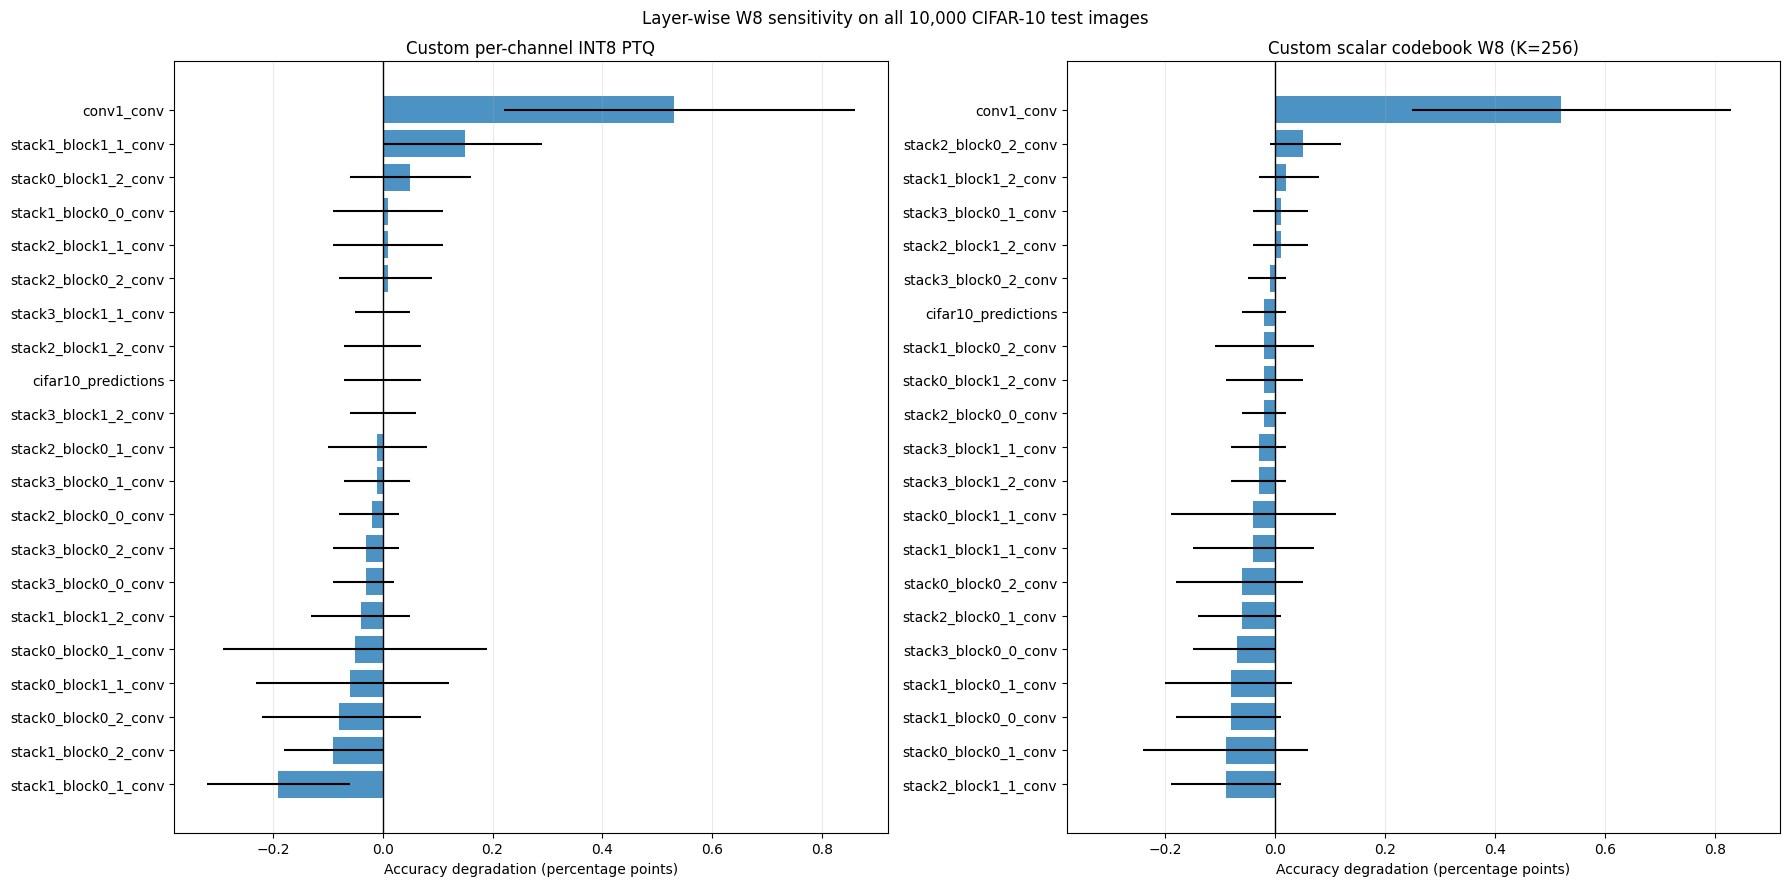

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharex=True)
for axis, (method, label) in zip(axes, METHODS.items()):
    group = ranked_results[ranked_results.method == method].sort_values("accuracy_degradation_pp")
    lower_error = group["accuracy_degradation_pp"] - group["bootstrap_ci_low_pp"]
    upper_error = group["bootstrap_ci_high_pp"] - group["accuracy_degradation_pp"]
    axis.barh(group["layer"], group["accuracy_degradation_pp"], xerr=[lower_error, upper_error], alpha=0.8)
    axis.axvline(0, color="black", linewidth=1)
    axis.set_title(label)
    axis.set_xlabel("Accuracy degradation (percentage points)")
    axis.grid(axis="x", alpha=0.25)
fig.suptitle("Layer-wise W8 sensitivity on all 10,000 CIFAR-10 test images")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure1_layer_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

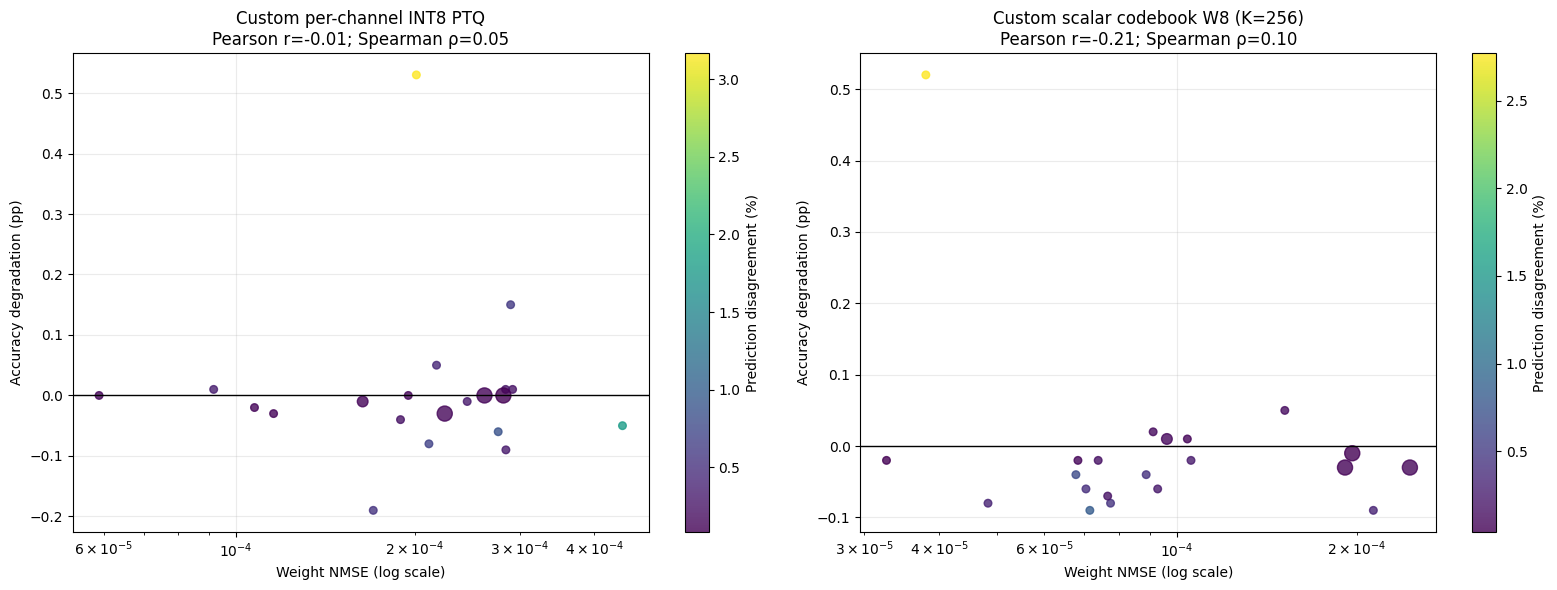

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for axis, (method, label) in zip(axes, METHODS.items()):
    group = layerwise_results[layerwise_results.method == method]
    scatter = axis.scatter(
        group["weight_nmse"], group["accuracy_degradation_pp"],
        s=np.maximum(30, group["parameter_count"] / 20_000),
        c=group["prediction_disagreement_percent"], cmap="viridis", alpha=0.8,
    )
    corr = correlation_table[(correlation_table.method == method) & (correlation_table.error_metric == "weight_nmse") & (correlation_table.response_metric == "accuracy_degradation_pp")].iloc[0]
    axis.set_xscale("log")
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title(f"{label}\nPearson r={corr.pearson_r:.2f}; Spearman ρ={corr.spearman_rho:.2f}")
    axis.set_xlabel("Weight NMSE (log scale)")
    axis.set_ylabel("Accuracy degradation (pp)")
    axis.grid(alpha=0.25)
    fig.colorbar(scatter, ax=axis, label="Prediction disagreement (%)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure2_error_vs_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

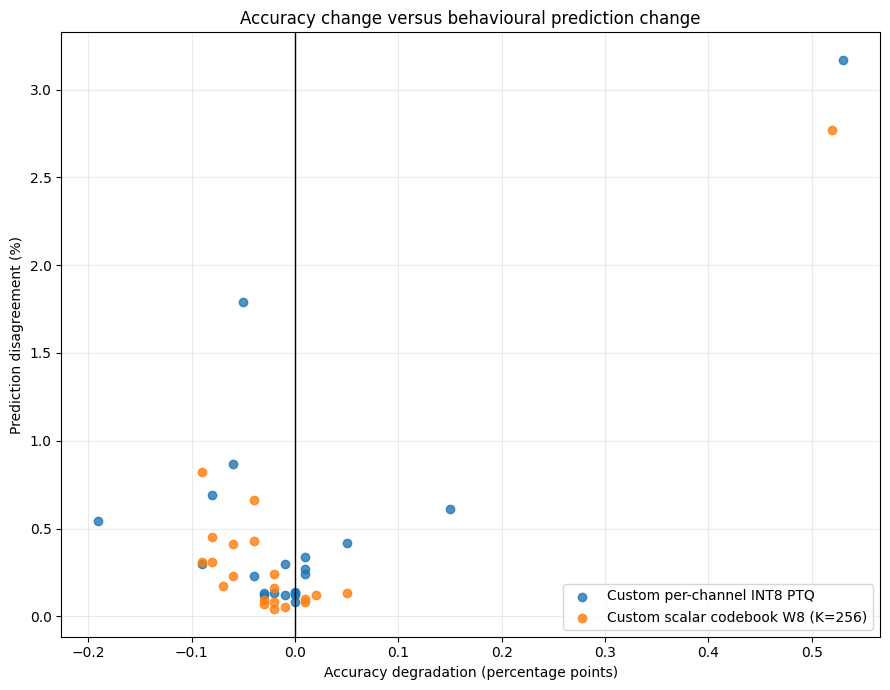

In [18]:
fig, axis = plt.subplots(figsize=(9, 7))
for method, label in METHODS.items():
    group = layerwise_results[layerwise_results.method == method]
    axis.scatter(group["accuracy_degradation_pp"], group["prediction_disagreement_percent"], label=label, alpha=0.8)
axis.axvline(0, color="black", linewidth=1)
axis.set_xlabel("Accuracy degradation (percentage points)")
axis.set_ylabel("Prediction disagreement (%)")
axis.set_title("Accuracy change versus behavioural prediction change")
axis.legend()
axis.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure3_accuracy_vs_disagreement.png", dpi=180, bbox_inches="tight")
plt.show()

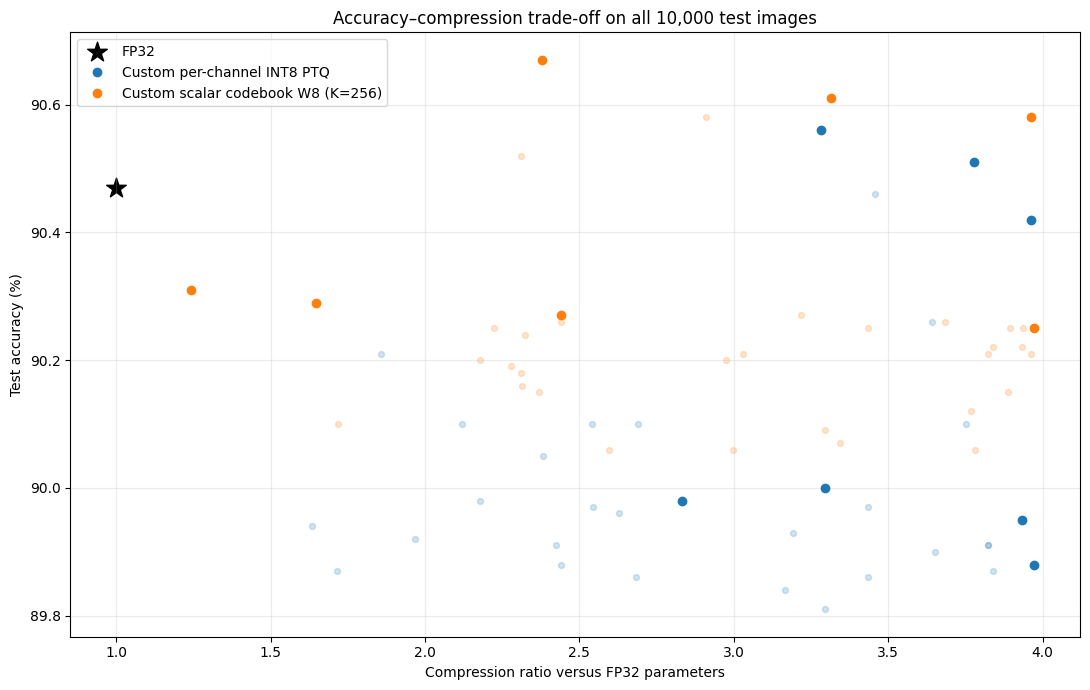

In [19]:
fig, axis = plt.subplots(figsize=(11, 7))
axis.scatter([1.0], [fp32_accuracy * 100], marker="*", s=220, color="black", label="FP32")
for method, label in METHODS.items():
    group = nonrandom_results[nonrandom_results.method == method]
    axis.plot(group["compression_ratio_vs_fp32"], group["accuracy_percent"], "o", label=label)
    random_group = configuration_results[(configuration_results.method == method) & configuration_results.configuration.str.startswith("random_")]
    axis.scatter(random_group["compression_ratio_vs_fp32"], random_group["accuracy_percent"], s=18, alpha=0.2)
axis.set_xlabel("Compression ratio versus FP32 parameters")
axis.set_ylabel("Test accuracy (%)")
axis.set_title("Accuracy–compression trade-off on all 10,000 test images")
axis.grid(alpha=0.25)
axis.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure4_accuracy_compression_tradeoff.png", dpi=180, bbox_inches="tight")
plt.show()

## 12. Reproducibility record and final tables

In [20]:
ranked_results.to_csv(OUTPUT_DIR / "final_ranked_layer_sensitivity.csv", index=False)
candidate_table.to_csv(OUTPUT_DIR / "common_tensor_coverage.csv", index=False)
run_metadata = {
    "model_checkpoint": str(MODEL_PATH),
    "checkpoint_modified_time": MODEL_PATH.stat().st_mtime,
    "dataset": "CIFAR-10 official test split",
    "test_images": NUM_TEST_IMAGES,
    "random_seed": RANDOM_SEED,
    "batch_size": BATCH_SIZE,
    "methods": METHODS,
    "ptq": {"bits": 8, "symmetric": True, "per_channel": PTQ_PER_CHANNEL},
    "codebook": {
        "assignment_bits": 8, "codebook_size": CODEBOOK_SIZE,
        "vector_dim": CODEBOOK_VECTOR_DIM, "codebook_dtype": str(CODEBOOK_DTYPE),
        "iterations": CODEBOOK_ITERATIONS, "max_samples": CODEBOOK_MAX_SAMPLES,
    },
    "common_quantized_tensors": len(candidate_table),
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "random_control_repetitions": RANDOM_CONTROL_REPETITIONS,
    "top_k_values": TOP_K_VALUES,
    "activations_quantized": False,
    "fake_quantization_used": False,
    "selection_bias_warning": "Selective configurations are exploratory because sensitivity ranking and evaluation use the same test split.",
    "tensorflow_version": tf.__version__,
    "keras_version": keras.__version__,
    "scipy_version": scipy.__version__,
    "python_version": sys.version,
    "hardware": platform.platform(),
    "cache_version": CACHE_VERSION,
}
(OUTPUT_DIR / "run_metadata.json").write_text(json.dumps(run_metadata, indent=2, default=str))
print(f"All results and figures saved under: {OUTPUT_DIR}")
print("Every reported accuracy and disagreement value used all 10,000 CIFAR-10 test images.")

All results and figures saved under: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_full_layer_sensitivity
Every reported accuracy and disagreement value used all 10,000 CIFAR-10 test images.


## Interpretation rules

- A positive `accuracy_degradation_pp` means quantization reduced accuracy.
- Prediction disagreement can be non-zero even when aggregate accuracy is unchanged.
- MSE/NMSE correlation does not establish causality and is based on a small number of layers.
- Individual layer drops must not be added to predict full-model degradation because quantization errors interact.
- Reconstructed Keras models do not demonstrate integer execution speed or physically compressed `.keras` files. Storage values describe the mathematical quantized representations, including PTQ scale or codebook overhead.
- Use the complete layer analysis descriptively. For an unbiased selective-precision claim, select layers on validation data and reserve the test set for a single final evaluation.